Analyzing...
1. shape of data
2. feature data types
3. classification balance
4. missing values

In [413]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder


In [414]:
data = pd.read_csv("../data/raw/term-deposit-marketing-2020.csv")

In [415]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


! need to make categorical variables into numerical data types so that data is consistent 

In [416]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  str  
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  str  
 7   loan       40000 non-null  str  
 8   contact    40000 non-null  str  
 9   day        40000 non-null  int64
 10  month      40000 non-null  str  
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  str  
dtypes: int64(5), str(9)
memory usage: 4.3 MB


In [417]:
counts = data.y.value_counts()
print("Positive Classification :",
      round(counts.iloc[1]/counts.iloc[0] * 100), "%")



Positive Classification : 8 %


In [418]:
data.describe()

,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000


In [419]:
#finding columns with unknown values
for column in data:
    print(column)
    print(data[column].unique())

age
[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81]
job
<StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',         'admin',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str
marital
<StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
education
<StringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str
default
<StringArray>
['no', 'yes']
Length: 2, dtype: str
balance
[  2143     29      2 ...   7222   3402 102127]
housing
<StringArray>
['yes', 'no']
Length: 2, dtype: str
loan
<StringArray>
['no', 'yes']
Length: 2, dtype: str
contact
<StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str
day
[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 2

In [420]:
#extracting columns with unknown values
print("Count unknown job",(data.job == "unknown").sum())
print("Count unknown education",(data.education == "unknown").sum())
print("Count unknown contact method",(data.contact == "unknown").sum())


Count unknown job 235
Count unknown education 1531
Count unknown contact method 12765


* Contact method may not correlate to subscription rate, so the missing feature may be okay. We will have to investigate further
* For job and education, these make up less than 5% of the data. 
* Before we remove any rows or features, I want to ensure that this data are missing by random. Let's check the distribution of rows with unknown education, job, and contact method.

# Encoding categorical and binary variables

In [421]:
#map binary categories
encoded_df_temp = data.copy() #preserve original data

encoded_df_temp['y'] = data['y'].map({'no': False, 'yes': True})  
encoded_df_temp['default'] = data['default'].map({'no': False, 'yes': True}) 
encoded_df_temp['housing'] = data['housing'].map({'no': False, 'yes': True}) 
encoded_df_temp['loan'] = data['loan'].map({'no': False, 'yes': True}) 

encoded_df_temp.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,False,2143,True,False,unknown,5,may,261,1,False
1,44,technician,single,secondary,False,29,True,False,unknown,5,may,151,1,False
2,33,entrepreneur,married,secondary,False,2,True,True,unknown,5,may,76,1,False
3,47,blue-collar,married,unknown,False,1506,True,False,unknown,5,may,92,1,False
4,33,unknown,single,unknown,False,1,False,False,unknown,5,may,198,1,False


In [422]:
#encode rest of categories
encoded_df = pd.get_dummies(encoded_df_temp, 
                              columns=['job','marital','education','contact','month'], 
                              drop_first=True)

encoded_df.head(5)

,age,default,balance,housing,loan,day,duration,campaign,y,job_blue-collar,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,58,False,2143,True,False,5,261,1,False,False,...,False,False,False,False,False,False,False,True,False,False
1,44,False,29,True,False,5,151,1,False,False,...,False,False,False,False,False,False,False,True,False,False
2,33,False,2,True,True,5,76,1,False,False,...,False,False,False,False,False,False,False,True,False,False
3,47,False,1506,True,False,5,92,1,False,True,...,False,False,False,False,False,False,False,True,False,False
4,33,False,1,False,False,5,198,1,False,False,...,False,False,False,False,False,False,False,True,False,False


In [423]:
encoded_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  40000 non-null  int64
 1   default              40000 non-null  bool 
 2   balance              40000 non-null  int64
 3   housing              40000 non-null  bool 
 4   loan                 40000 non-null  bool 
 5   day                  40000 non-null  int64
 6   duration             40000 non-null  int64
 7   campaign             40000 non-null  int64
 8   y                    40000 non-null  bool 
 9   job_blue-collar      40000 non-null  bool 
 10  job_entrepreneur     40000 non-null  bool 
 11  job_housemaid        40000 non-null  bool 
 12  job_management       40000 non-null  bool 
 13  job_retired          40000 non-null  bool 
 14  job_self-employed    40000 non-null  bool 
 15  job_services         40000 non-null  bool 
 16  job_student          40000 non-nu

# Testing Correlation

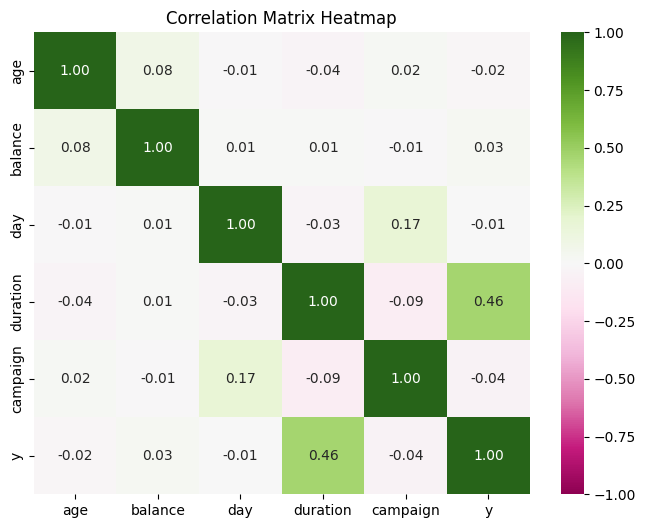

In [424]:
#Finding correlation of continuous values to subscription rate using correlation matrix
corr_matrix = encoded_df[['age','balance','day','duration','campaign','y']].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show values inside cells
    cmap='PiYG',
    vmin=-1, vmax=1,     # Bound color scale between -1 and 1
    fmt=".2f"            # Round to 2 decimal places
)
plt.title('Correlation Matrix Heatmap')
plt.show()


Of the continuous values, 'duration' and 'campaign' are the most correlated to 'y'.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_28663/46539868.py:1: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(encoded_df_temp, x='job', y='y', color="#839791", errcolor="#e3307d")


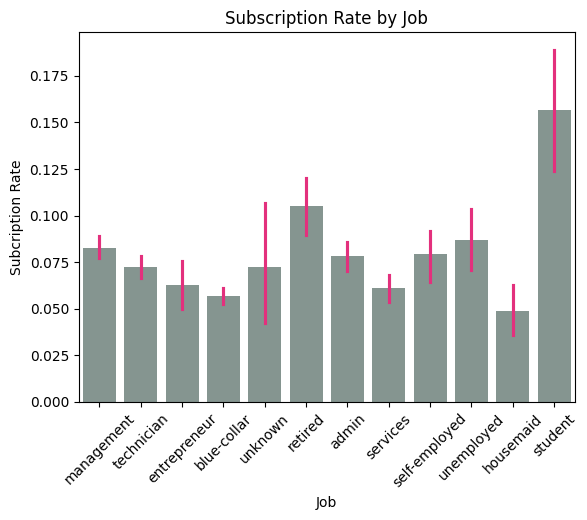

In [425]:
plot = sns.barplot(encoded_df_temp, x='job', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Job')
plt.xticks(rotation=45)
plt.ylabel('Subcription Rate')
plt.title('Subscription Rate by Job')
plt.show()

* Students have the highest term deposit subscription rate. 
* 'Retired', 'management', 'admin' and 'unemployed' look to be likely to subscribe to a term deposit, but more analysis may need to be done to prove statistical significance. 
* Those who declined to submit their job do not have an exceptionally low or high subscription rate. We can safely remove these missing values. 

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_28663/1189419218.py:1: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(encoded_df_temp, x='marital', y='y', color="#839791", errcolor="#e3307d")


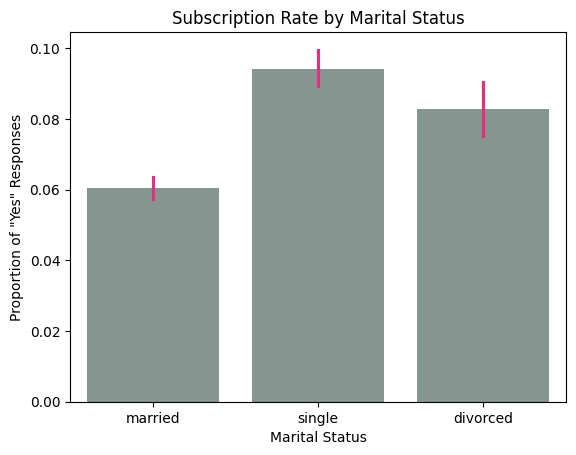

In [426]:
plot = sns.barplot(encoded_df_temp, x='marital', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Marital Status')
plt.ylabel('Proportion of "Yes" Responses')
plt.title('Subscription Rate by Marital Status')
plt.show()

Single customers may have a statistically significant, higher subscription rate than married or divorced customers

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_28663/846081117.py:1: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(encoded_df_temp, x='education', y='y', color="#839791", errcolor="#e3307d")


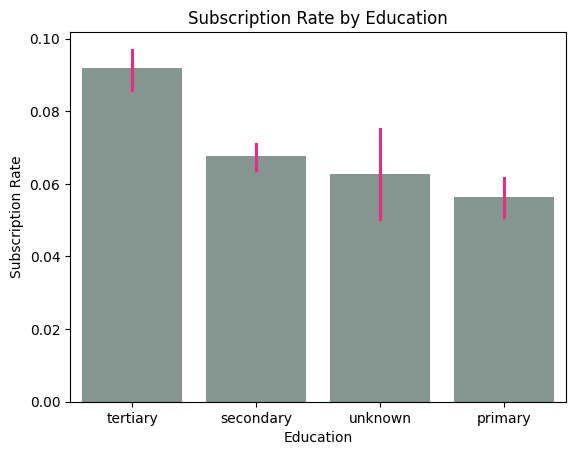

In [427]:
plot = sns.barplot(encoded_df_temp, x='education', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Education')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Education')
plt.show()

* Those whose education status was marked as tertiary have the highest term deposit subscription rate.
* Those who declined to submit their education do not have an exceptionally low or high subscription rate. We can safely remove these missing values. 

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_28663/1208943164.py:1: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(encoded_df_temp, x='default', y='y', color="#839791", errcolor="#e3307d")


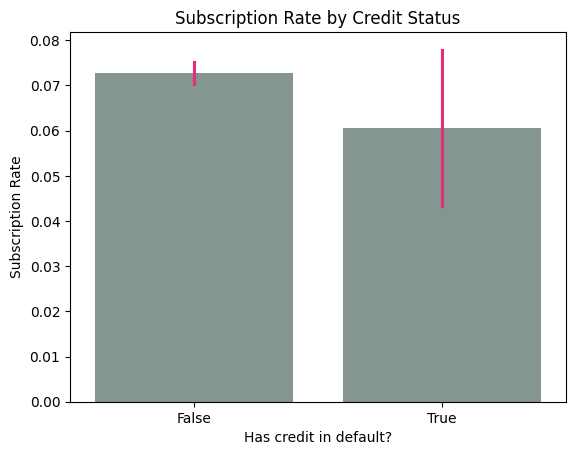

In [428]:
plot = sns.barplot(encoded_df_temp, x='default', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Has credit in default?')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Credit Status')
plt.show()

The credit status does not seem to be highly correlated to subscription rate as the error bars greatly overlap.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_28663/1918284396.py:1: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(encoded_df_temp, x='loan', y='y', color="#839791", errcolor="#e3307d")


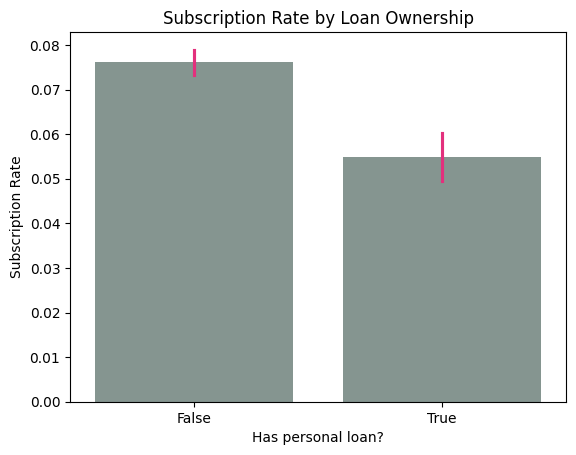

In [429]:
plot = sns.barplot(encoded_df_temp, x='loan', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Has personal loan?')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Loan Ownership')
plt.show()

Customers without a personal loan may look to have a larger subscription rate than those without a personal loan, but more analysis will need to be done to ensure statistical significance as the scale shown here is very small.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_28663/2834558367.py:1: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(encoded_df_temp, x='contact', y='y', color="#839791", errcolor="#e3307d")


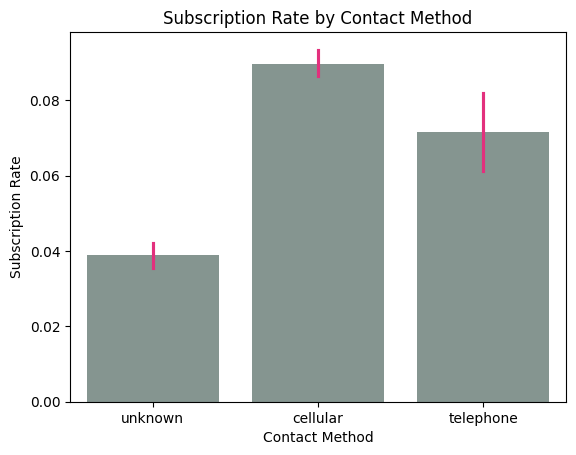

In [430]:
plot = sns.barplot(encoded_df_temp, x='contact', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Contact Method')
plt.show()

It looks like those with an unknown contact method have a much lower subscription rate. This may be due to customers asking to be taken off calling lists. 
I'm curious to see how the model would perform keeping the rows with the missing values vs. removing the feature entirely.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_28663/1437697871.py:1: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(encoded_df_temp, x='day', y='y', color="#839791", errcolor="#e3307d")


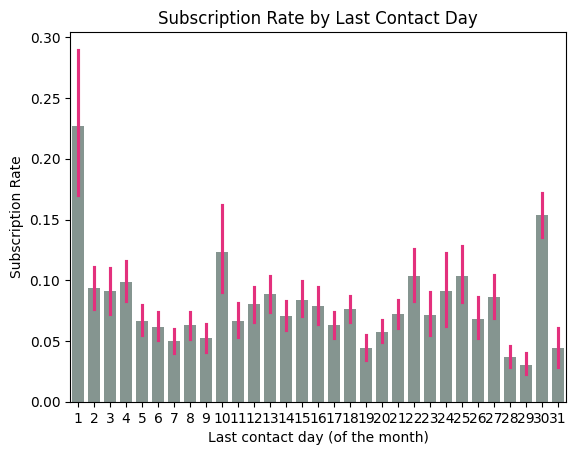

In [431]:
plot = sns.barplot(encoded_df_temp, x='day', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Last contact day (of the month)')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Last Contact Day')
plt.show()

End Through the 1st of each month have the highest subscription rates.

/var/folders/2t/jlwt4t955m5g3f49k1zzh5100000gn/T/ipykernel_28663/2057382497.py:1: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#e3307d'}` instead.

  plot = sns.barplot(encoded_df_temp, x='month', y='y', color="#839791", errcolor="#e3307d")


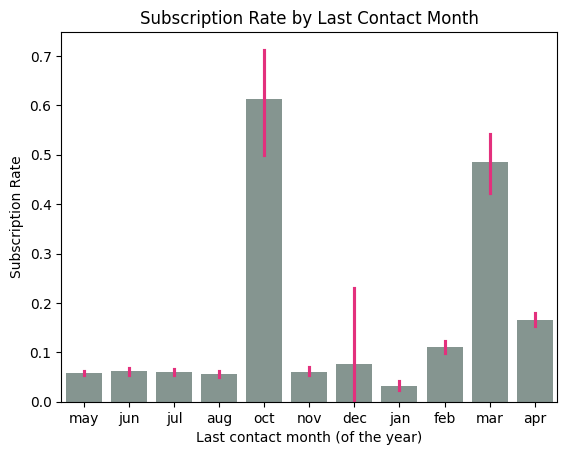

In [432]:
plot = sns.barplot(encoded_df_temp, x='month', y='y', color="#839791", errcolor="#e3307d")

plt.xlabel('Last contact month (of the year)')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Last Contact Month')
plt.show()

Why do October and March particularly have high subscription rates? Does it have to do with financial quarters?


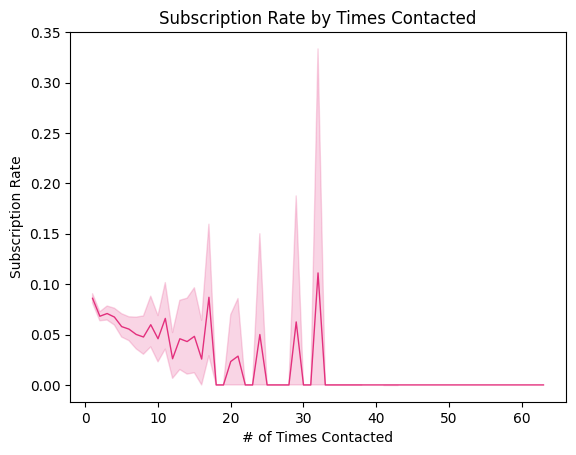

In [433]:
plot = sns.lineplot(encoded_df_temp, x='campaign', y='y', color="#e3307d", linewidth=1, )

plt.xlabel('# of Times Contacted')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Times Contacted')
plt.show()

Subscription rate falls as times contacted increases. Though there are some sharp blimps in this pattern, the error margin shows that this could be due to small sample size.

# Removing Missing Values

In [434]:
encoded_df.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration',
       'campaign', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'contact_telephone',
       'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct'],
      dtype='str')

In [436]:
#taking out rows with missing values
encoded_df_no_missing = encoded_df.copy()
encoded_df_no_missing = encoded_df[encoded_df['job_unknown'] != True] 
encoded_df_no_missing = encoded_df[encoded_df['education_unknown'] != True]
encoded_df_with_contact = encoded_df_no_missing.copy()
encoded_df_no_missing = encoded_df[encoded_df['contact_unknown'] != True]

#removing features
encoded_df_no_missing.drop(columns=['job_unknown','education_unknown','contact_unknown'], inplace=True)
encoded_df_with_contact.drop(columns=['job_unknown','education_unknown','contact_unknown'], inplace=True)